# Lab 5

https://github.com/MTG/machine_learning_for_sound_and_music_25/blob/main/notebooks/07_01_metric_learning.ipynb

## Introduction

Apply contrastive learning similar to the class notebook to train a model using the
MagnaTagATune (MTAT) dataset
1. Adapt the provided implementation and train the model on MTAT
* You can reuse the data loading code from the previous assignment.
2. Evaluate the quality of embeddings
* Visualize various tags in a 2D plot reusing the code provided in the notebook. The dataset is
multilabel, therefore, create separate plots for two tags groups of your decision, selecting tags
that do not overlap (for example: era: 2000s, 90s, 80s, genre: rock, pop, …)
3. Write a short report documenting your decisions and observations
* The report should be included in the notebook
* The notebook should be self-explanatory, and executable (i.e., it should contain the code to
install dependencies and setup the dataset). The assignment will be entirely evaluated on the
contents of the notebook.

## Imports

In [1]:
#!pip install torchmetrics -q
!pip install torch-audiomentations -q
!pip install torchcodec -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 23.5 MB/s eta 0:00:00


In [2]:
import os
from google.colab import drive
from google.colab import files
import pandas as pd
import zipfile
import matplotlib.pyplot as plt
import numpy as np
import librosa.display
import librosa
import glob
import random

# Import necessary libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import torchaudio

from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, Dataset
from torchaudio.transforms import MelSpectrogram, Resample
from tqdm.autonotebook import tqdm

from torch_audiomentations import (
    Compose,
    Gain,
    PolarityInversion,
    AddBackgroundNoise,
    AddColoredNoise,
    BandStopFilter,
    ApplyImpulseResponse,
    PitchShift,
    LowPassFilter,
)

import umap
import seaborn as sns

# Metrics
# import torchmetrics
# from sklearn.metrics import classification_report

/tmp/ipython-input-3118437487.py:25: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [3]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

## Data Importing

### Importing

#### Importing Tags

In [4]:
if not os.path.isdir("/content/drive"):
  drive.mount('/content/drive')

In [5]:
try:
  df = pd.read_csv('/content/drive/MyDrive/SMC/MLSM/Lab3/annotations_final.csv', sep="\t", index_col=0)
except FileNotFoundError:
  uploaded = files.upload()
  df = pd.read_csv(list(uploaded.keys())[0], skipinitialspace = True)
except Exception as e:
  print(f"An error occurred: {e}")
  df = None

if df is not None:
    print(df.head())

         no voice  singer  duet  plucking  hard rock  world  bongos  \
clip_id                                                               
2               0       0     0         0          0      0       0   
6               0       0     0         0          0      0       0   
10              0       0     0         0          0      0       0   
11              0       0     0         0          0      0       0   
12              0       0     0         0          0      0       0   

         harpsichord  female singing  clasical  ...  rap  metal  hip hop  \
clip_id                                         ...                        
2                  0               0         0  ...    0      0        0   
6                  0               0         0  ...    0      0        0   
10                 0               0         0  ...    0      0        0   
11                 0               0         0  ...    0      0        0   
12                 0               0         0

#### Importing Audios

In [6]:
FINAL_ZIP_NAME = 'magna_tag_atune_complete.zip'
DESTINATION_FOLDER = 'dataset'
BASE_PATH = '/content/drive/MyDrive/SMC/MLSM/Lab3' # Set this to the directory where your .001 files are located

with zipfile.ZipFile(os.path.join(BASE_PATH, FINAL_ZIP_NAME), 'r') as zf:
    zf.extractall(DESTINATION_FOLDER)

print(f"Success! All audio clips have been extracted to: {DESTINATION_FOLDER}")

Success! All audio clips have been extracted to: dataset


## Datasets

### Selecting Top 50 Tags

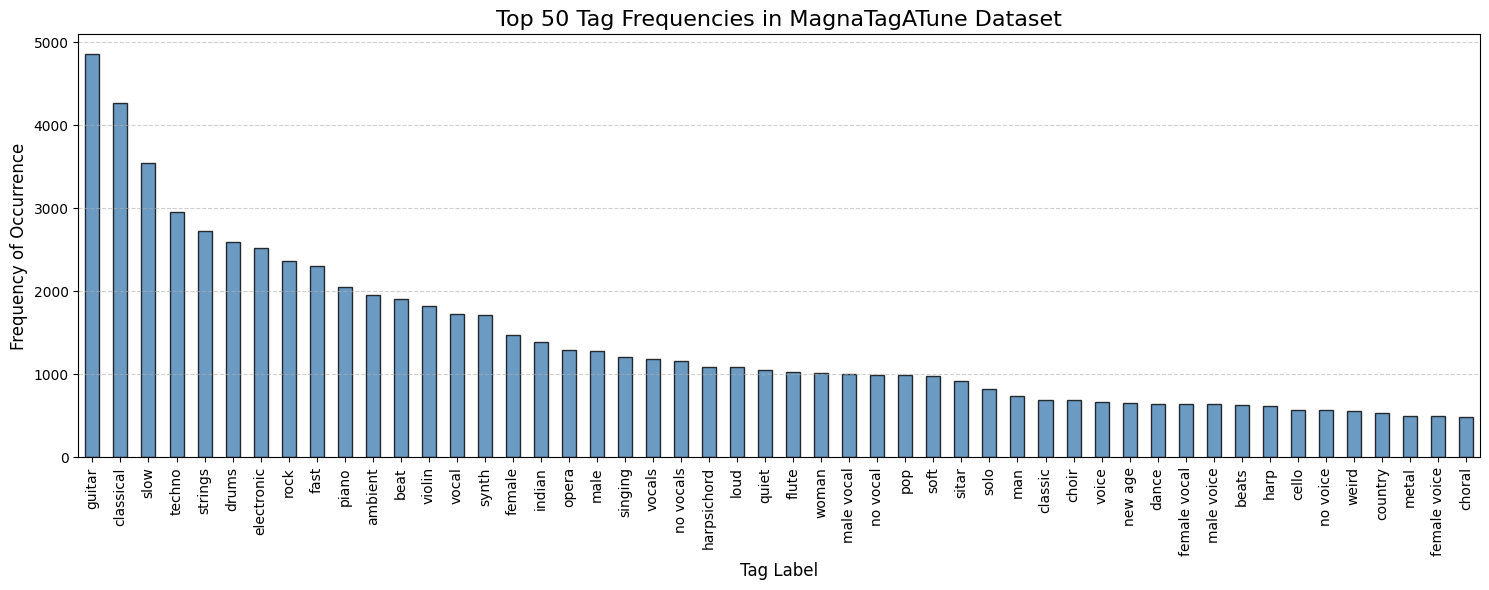

In [7]:
# 1. Calculate and select the top 50 tag counts
# df.iloc[:, :-1] selects all columns except the last one (assuming the last one is NOT a tag, e.g., clip_id)
tag_counts = df.iloc[:, :-1].sum().sort_values(ascending=False)
top_50_counts = tag_counts[:50]

# 2. Configure plot aesthetics
plt.figure(figsize=(15, 6)) # Better aspect ratio for bars

# 3. Create the bar plot directly
ax = top_50_counts.plot.bar(
    rot=90,             # Rotate x-labels for readability
    color='steelblue',  # Set a nice color
    edgecolor='k',      # Black border for clarity
    alpha=0.8
)

# 4. Set labels and title
ax.set_title('Top 50 Tag Frequencies in MagnaTagATune Dataset', fontsize=16)
ax.set_xlabel('Tag Label', fontsize=12)
ax.set_ylabel('Frequency of Occurrence', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.6) # Add light grid lines

plt.tight_layout()
plt.show()

In [8]:
top_50_counts.index

Index(['guitar', 'classical', 'slow', 'techno', 'strings', 'drums',
       'electronic', 'rock', 'fast', 'piano', 'ambient', 'beat', 'violin',
       'vocal', 'synth', 'female', 'indian', 'opera', 'male', 'singing',
       'vocals', 'no vocals', 'harpsichord', 'loud', 'quiet', 'flute', 'woman',
       'male vocal', 'no vocal', 'pop', 'soft', 'sitar', 'solo', 'man',
       'classic', 'choir', 'voice', 'new age', 'dance', 'female vocal',
       'male voice', 'beats', 'harp', 'cello', 'no voice', 'weird', 'country',
       'metal', 'female voice', 'choral'],
      dtype='object')

In [9]:
df_top50 = df[[c for c in top_50_counts.index] + ['mp3_path']]
df_top50.shape

(25863, 51)

In [10]:
tags = df.drop(columns=["mp3_path"]).columns.tolist()
df.apply(
    lambda row: row[tags][row[tags] == 1].index.tolist(),
    axis=1
)

,0
clip_id,
2,"[classical, strings, opera, violin]"
6,"[classical, violins, strings, classic, opera, ..."
10,"[classical, classic, opera]"
11,"[quiet, opera]"
12,"[classical, violins, strings, classic, violin]"
...,...
58899,"[guitar, classical guitar]"
58906,"[guitar, solo, strings, medieval, harp, slow, ..."
58907,"[classical, guitar, strings, slow]"


In [11]:
df.shape, df_top50.shape

((25863, 189), (25863, 51))

### Generate Datasets

In [12]:
class MagnaTagATuneDataset(Dataset):
    "Multiview MTAT Dataset for Contrastive Learning (Lazy Loading)"
    def __init__(self, root_dir, annotations_df, subset='train', sample_rate=16000, duration=3):
        self.root_dir = root_dir
        self.sample_rate = sample_rate
        self.audio_duration = duration
        self.max_separation = 1.0  # Seconds

        # Calculate exact required samples
        self.n_samples = int(self.sample_rate * self.audio_duration)

        # Folder split mapping
        self.split_map = {
            'train': [str(i) for i in range(10)] + ['a', 'b'],
            'val': ['c'],
            'test': ['d', 'e', 'f']
        }

        if subset not in self.split_map:
            raise ValueError(f"Invalid subset: '{subset}'. Use: {list(self.split_map.keys())}")

        target_folders = set(self.split_map[subset])

        # Filter the dataframe by subset folders
        subset_df = annotations_df[annotations_df['mp3_path'].apply(
            lambda x: x.split('/')[0] in target_folders
        )].copy()

        self.paths = subset_df['mp3_path'].tolist()

        # Binary Labels (Matrix of 0s and 1s)
        label_cols = subset_df.drop(columns=['mp3_path', 'clip_id'], errors='ignore')
        self.labels = label_cols.values.astype(np.float32)

        # Tag names (to convert binary vectors back to strings)
        self.tag_names_np = np.array(label_cols.columns.tolist())

    def __len__(self):
        return len(self.paths)

    def load_audio_robust(self, mp3_path):
        """Loads audio and guarantees a 1D flattened vector."""
        full_path = os.path.join(self.root_dir, mp3_path)

        # Fallback to zeros if loading fails (safety margin of 4x duration)
        fallback = torch.zeros(self.n_samples * 4)

        if not os.path.exists(full_path):
            return fallback

        try:
            waveform, sr = torchaudio.load(full_path, normalize=True)

            # Stereo -> Mono
            if waveform.shape[0] > 1:
                waveform = torch.mean(waveform, dim=0, keepdim=True)

            # Resample
            if sr != self.sample_rate:
                resampler = torchaudio.transforms.Resample(sr, self.sample_rate)
                waveform = resampler(waveform)

            # CRITICAL: Flatten to 1D vector to ensure stackability
            waveform = waveform.flatten()

            return waveform

        except Exception:
            return fallback

    def get_crop(self, audio, start, end):
        """Extracts a crop and pads with zeros if audio is too short."""
        crop = audio[start:end]

        if crop.shape[0] < self.n_samples:
            padding = self.n_samples - crop.shape[0]
            crop = torch.nn.functional.pad(crop, (0, padding))

        return crop

    def __getitem__(self, idx):
        # 1. Binary Labels
        labels_binary = self.labels[idx]

        # 2. Natural Labels (GTZAN-style string conversion)
        # We join tags into a single string "tag1,tag2" to avoid collate_fn issues
        mask = labels_binary.astype(bool)
        tags_list = self.tag_names_np[mask].tolist()
        natural_labels_str = ",".join(tags_list)

        # 3. Audio Loading
        mp3_path = self.paths[idx]
        audio_full = self.load_audio_robust(mp3_path)

        # Preventive padding if the total file is shorter than duration
        if audio_full.shape[0] < self.n_samples:
            padding = self.n_samples - audio_full.shape[0]
            audio_full = torch.nn.functional.pad(audio_full, (0, padding))

        # 4. Contrastive Cropping Logic
        max_start = max(0, audio_full.shape[0] - self.n_samples)

        # View 1: Random start
        start_1 = random.randint(0, max_start)
        view_1 = self.get_crop(audio_full, start_1, start_1 + self.n_samples)

        # View 2: Random start close to start_1
        sep_samples = int(self.max_separation * self.sample_rate)
        min_2 = max(0, start_1 - sep_samples)
        max_2 = min(max_start, start_1 + sep_samples)

        if max_2 < min_2: max_2 = min_2
        start_2 = random.randint(min_2, max_2)

        view_2 = self.get_crop(audio_full, start_2, start_2 + self.n_samples)

        return {
            "view_1": view_1,
            "view_2": view_2,
            "labels": torch.tensor(labels_binary, dtype=torch.float32),
            "natural_labels": natural_labels_str # Returns STRING
        }

In [13]:
train_dataset = MagnaTagATuneDataset(
    root_dir='dataset',
    annotations_df=df_top50,
)

val_dataset = MagnaTagATuneDataset(
    root_dir='dataset',
    annotations_df=df_top50,
    subset='val'
)

test_dataset = MagnaTagATuneDataset(
    root_dir='dataset',
    annotations_df=df_top50,
    subset='test'
)

# Change depending on GPU capacity.
# Currently training on A100 High-RAM in Colab
BATCH_SIZE = 512

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## Models

### Auxiliar Functions

In [14]:
def train(
    model,
    loss_fn,
    n_epochs=10, # Adjusted to your log
    lr=0.001,
    device="cuda",
    augment=True,
    train_loader=train_loader,
    val_loader=val_loader
):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(n_epochs):
        # --- Training Loop ---
        model.train()
        total_loss = 0

        # Create the progress bar
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{n_epochs}", leave=True)

        for batch in progress_bar:
            x1 = batch["view_1"].to(device)
            x2 = batch["view_2"].to(device)

            if augment:
                x1 = augmentation_chain(x1)
                x2 = augmentation_chain(x2)

            x1 = feature_extractor(x1).unsqueeze(1)
            x2 = feature_extractor(x2).unsqueeze(1)

            z1 = model(x1)
            z2 = model(x2)
            loss = loss_fn(z1, z2)

            # Update metrics
            current_loss = loss.item()
            total_loss += current_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Show the current BATCH loss in the progress bar
            progress_bar.set_postfix(batch_loss=f"{current_loss:.4f}")

        # Calculate average training loss for the epoch
        train_loss = total_loss / len(train_loader)

        # --- Validation Loop ---
        model.eval()
        total_val_loss = 0

        with torch.no_grad():
            for batch in val_loader:
                x1 = batch["view_1"].to(device)
                x2 = batch["view_2"].to(device)
                # Note: Usually we do NOT augment in validation, but keeping your logic:
                if augment:
                    x1 = augmentation_chain(x1)
                    x2 = augmentation_chain(x2)

                x1 = feature_extractor(x1).unsqueeze(1)
                x2 = feature_extractor(x2).unsqueeze(1)

                z1 = model(x1)
                z2 = model(x2)
                loss = loss_fn(z1, z2)

                total_val_loss += loss.item()

        val_loss = total_val_loss / len(val_loader)

        # --- THE FIX ---
        # Instead of trying to update the closed progress bar,
        # we print the summary below it using progress_bar.write()
        # (This keeps the progress bar intact visually)
        progress_bar.write(
            f"   Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}"
        )

### Models

In [15]:
# Feature extractor. Using mel-spectrogram

class FeatureExtractor(nn.Module):
    def __init__(self, **kwargs):
        super().__init__()
        self.melspectrogram = MelSpectrogram(**kwargs)

    def forward(self, x):
        x = self.melspectrogram(x)
        x = torch.log10(1 + 1000 * x)  # Log-compression
        return x

In [16]:
class AugmentationChain(nn.Module):
    """Add a number of audio augmentaitons with probability p."""

    p = 0.75
    sr = 16000
    def __init__(self, **kwargs):
        super().__init__()
        self.chain = Compose(
            transforms=[
                Gain(p=self.p, output_type='tensor'),
                BandStopFilter(sample_rate=self.sr, p=self.p, output_type='tensor'),
                PitchShift(p=self.p, sample_rate=self.sr, output_type='tensor'),
                AddColoredNoise(p=self.p, output_type='tensor'),
                LowPassFilter(p=self.p, sample_rate=self.sr, min_cutoff_freq=400, output_type='tensor',),
            ]
            , output_type='tensor'
        )

    def forward(self, audio):
        return self.chain(audio.unsqueeze(1)).squeeze(1)

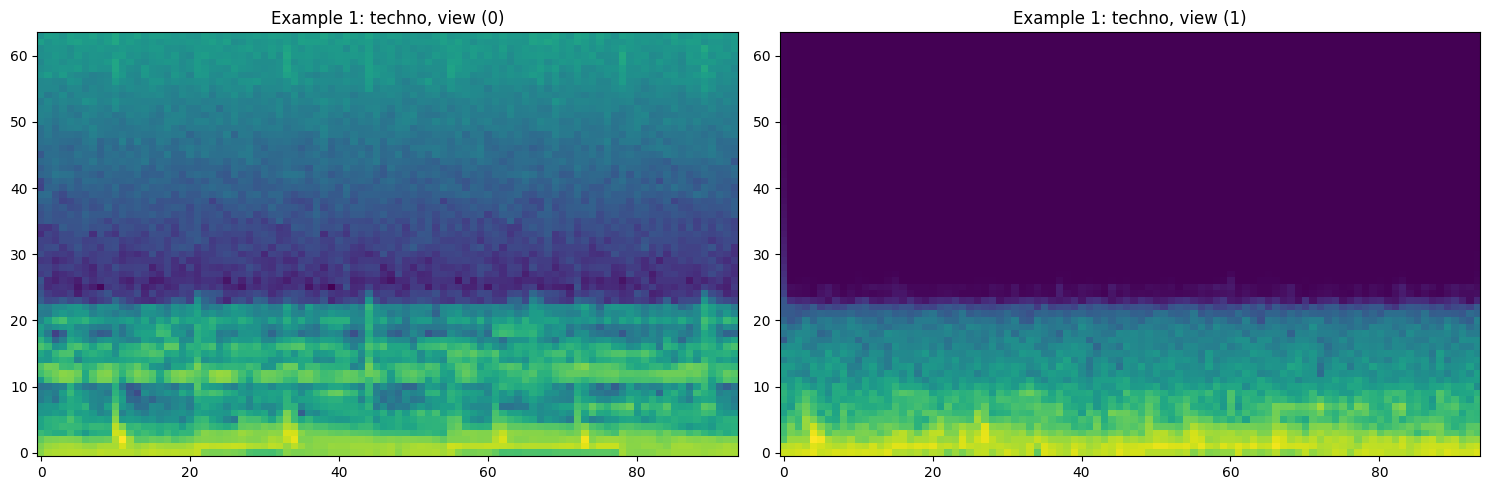

In [17]:
feature_extractor = FeatureExtractor(n_mels=64, n_fft=1024).to(device)
augmentation_chain = AugmentationChain().to(device)

# Fetch a batch of data
batch = next(iter(val_loader))

mel_specs_1 = feature_extractor(augmentation_chain(batch["view_1"].to(device))).cpu().numpy()
mel_specs_2 = feature_extractor(augmentation_chain(batch["view_2"].to(device))).cpu().detach().numpy()

# Visualize the first three mel-spectrograms in the batch
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for i, mels in enumerate([mel_specs_1, mel_specs_2]):
    axes[i].imshow(mels[0], aspect="auto", origin="lower")
    axes[i].set_title(f"Example {0+1}: {batch['natural_labels'][0]}, view ({i})")
plt.tight_layout()
plt.show()

In [18]:
n_classes = len((val_dataset.labels))

batch = next(iter(val_loader))
mels = feature_extractor(batch["view_1"].to(device))

print("Mel-spectrogram shape:", mels.shape)
print("Number of classes:", n_classes)

Mel-spectrogram shape: torch.Size([512, 64, 94])
Number of classes: 1825


In [19]:
class CNN(nn.Module):
    def __init__(
        self,
        kernel_size: int=3,
        pooling_size: int=4,
        dense_size: int=64,
        n_classes: int=10,
    ):
        super().__init__()
        self.dense_size = dense_size

        # --- CÁLCULO DE FEATURES ---
        # 1. Altura (Height): 64 / 4 / 4 / 4 = 1
        # 2. Ancho (Width): floor(907 / 4 / 4 / 4) = floor(14.17) = 14
        # 3. Canales finales: OUTPUT_FEATURES = Canales * Altura * Ancho = 64 * 1 * 14
        OUTPUT_FEATURES = dense_size * 1 * 1  # = 896

        self.conv1 = nn.Conv2d(1, dense_size // 4, kernel_size=kernel_size, stride=1, padding=1)
        self.conv2 = nn.Conv2d(dense_size // 4, dense_size // 2, kernel_size=kernel_size, stride=1, padding=1)
        self.conv3 = nn.Conv2d(dense_size // 2, dense_size, kernel_size=kernel_size, stride=1, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=pooling_size, stride=pooling_size)

        self.fc1 = nn.Linear(OUTPUT_FEATURES, dense_size)
        self.fc2 = nn.Linear(dense_size, n_classes)

    def forward(self, x):
        # x se asume que ya tiene la forma [32, 1, 64, 907]

        # Capas convolucionales y de pooling
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        # Forma antes de esta línea: [32, 64, 1, 14]

        # CORRECCIÓN: Aplanar de forma segura, preservando el batch size
        # Esto transforma [32, 64, 1, 14] a [32, 896]
        x = torch.flatten(x, start_dim=1)

        # Capas lineales
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

### Losses

In [20]:
def triplet_loss(anchor, positive, margin=1.0):
    # Pick a random negative from the batch (next sample)
    negative = torch.roll(positive, 1, dims=0)

    distance_positive = (anchor - positive).pow(2).sum(1)
    distance_negative = (anchor - negative).pow(2).sum(1)

    losses = F.relu(distance_positive - distance_negative + margin)
    return losses.mean()

In [21]:
def InfoNCE(z_1, z_2, temp=0.5):
    # Normalize the embeddings
    z_1 = F.normalize(z_1, dim=1)
    z_2 = F.normalize(z_2, dim=1)

    # Similarity matrices
    sim_12 = torch.matmul(z_1, z_2.T)  # z1 as anchor, z2 as candidates
    sim_21 = torch.matmul(z_2, z_1.T)  # z2 as anchor, z1 as candidates

    # Labels: each sample i should match its own pair i
    labels = torch.arange(sim_12.size(0)).to(sim_12.device)

    # InfoNCE losses (both directions)
    loss_12 = F.cross_entropy(sim_12 / temp, labels)
    loss_21 = F.cross_entropy(sim_21 / temp, labels)

    # Symmetric SimCLR loss
    return 0.5 * (loss_12 + loss_21)

### UMAP

UMAP is a dimension reduction technique that can be used for visualisation similarly to t-SNE, but also for general non-linear dimension reduction.

In [ ]:
def plot_mtat_embeddings(model, val_loader, priority_tags, device="cuda"):
    """
    Extracts embeddings ONLY for the specified priority_tags and plots them.
    Samples that don't match any tag in 'priority_tags' are ignored.

    Args:
        model: The trained encoder.
        val_loader: DataLoader for validation.
        priority_tags: List of tags you want to plot (e.g., ['rock', 'jazz']).
    """
    model.eval()
    model.to(device)

    embeddings = []
    plot_labels = []

    print(f"Extracting embeddings (Filtering for: {priority_tags})...")

    with torch.no_grad():
        for batch in tqdm(val_loader):
            # 1. Get Audio
            audio = batch['view_1'].to(device)

            x = feature_extractor(audio).unsqueeze(1)

            # 2. Forward Pass
            z = model(x)

            # Global Average Pooling if necessary (if output is [Batch, Dim, Time])
            if len(z.shape) > 2:
                z = torch.mean(z, dim=-1)

            z_np = z.cpu().numpy()

            # 3. Filter and Collect per Sample
            # We loop through each sample in the batch to decide if we keep it
            natural_labels_batch = batch['natural_labels']

            for i, tag_list in enumerate(natural_labels_batch):

                # Check if this song has any of the tags we want
                found_tag = None
                for target in priority_tags:
                    if target in tag_list:
                        found_tag = target
                        break # Stop at the first match found (Priority)

                # ONLY append if we found a matching tag
                if found_tag is not None:
                    embeddings.append(z_np[i])
                    plot_labels.append(found_tag)

    if len(embeddings) == 0:
        print("Error: No samples found matching your tags. Check the tag names.")
        return

    # Convert to numpy
    embeddings = np.array(embeddings)
    plot_labels = np.array(plot_labels)

    print(f"Running UMAP on {embeddings.shape[0]} filtered samples...")

    # Perform UMAP
    reducer = umap.UMAP(n_components=2, random_state=42)
    umap_embeddings = reducer.fit_transform(embeddings)

    # --- Plotting ---
    plt.figure(figsize=(10, 8))

    sns.scatterplot(
        x=umap_embeddings[:, 0],
        y=umap_embeddings[:, 1],
        hue=plot_labels,
        palette="tab10",
        s=15,
        alpha=0.8
    )

    plt.title(f"UMAP of Audio Embeddings (Filtered)")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.legend(title="Label", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [29]:
val_dataset.tag_names_np

array(['guitar', 'classical', 'slow', 'techno', 'strings', 'drums',
       'electronic', 'rock', 'fast', 'piano', 'ambient', 'beat', 'violin',
       'vocal', 'synth', 'female', 'indian', 'opera', 'male', 'singing',
       'vocals', 'no vocals', 'harpsichord', 'loud', 'quiet', 'flute',
       'woman', 'male vocal', 'no vocal', 'pop', 'soft', 'sitar', 'solo',
       'man', 'classic', 'choir', 'voice', 'new age', 'dance',
       'female vocal', 'male voice', 'beats', 'harp', 'cello', 'no voice',
       'weird', 'country', 'metal', 'female voice', 'choral'],
      dtype='<U12')

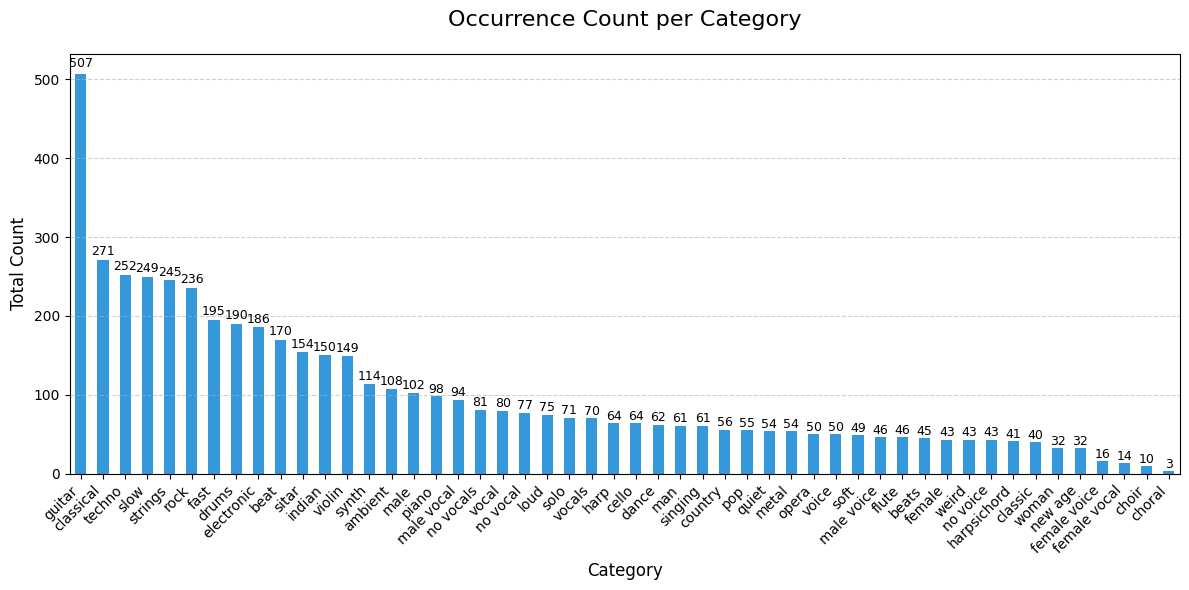

In [37]:
# --- 1. DATA PREPARATION ---
# Sum across rows to get total occurrences per tag
tag_counts_array = val_dataset.labels.sum(axis=0)

# Create Pandas Series to map counts to tag names
tag_names = val_dataset.tag_names_np
counts_series = pd.Series(tag_counts_array, index=tag_names)

# --- 2. PLOTTING ---
plt.figure(figsize=(12, 6))

# Sort values for a cleaner visualization
sorted_counts = counts_series.sort_values(ascending=False)
sorted_counts.plot(kind='bar', color='#3498DB')

plt.title('Occurrence Count per Category', fontsize=16, pad=20)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Count', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add text labels on top of bars
for i, v in enumerate(sorted_counts):
    plt.text(i, v + (v * 0.01), str(int(v)), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
cnn = CNN(dense_size=64, n_classes=64).to(device)

num_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print(f"CNN Trainable parameters: {num_params}")

CNN Trainable parameters: 31616


Extracting embeddings (Filtering for: ['classical', 'rock', 'electronic', 'techno'])...


  0%|          | 0/4 [00:00<?, ?it/s]

Running UMAP on 782 filtered samples...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


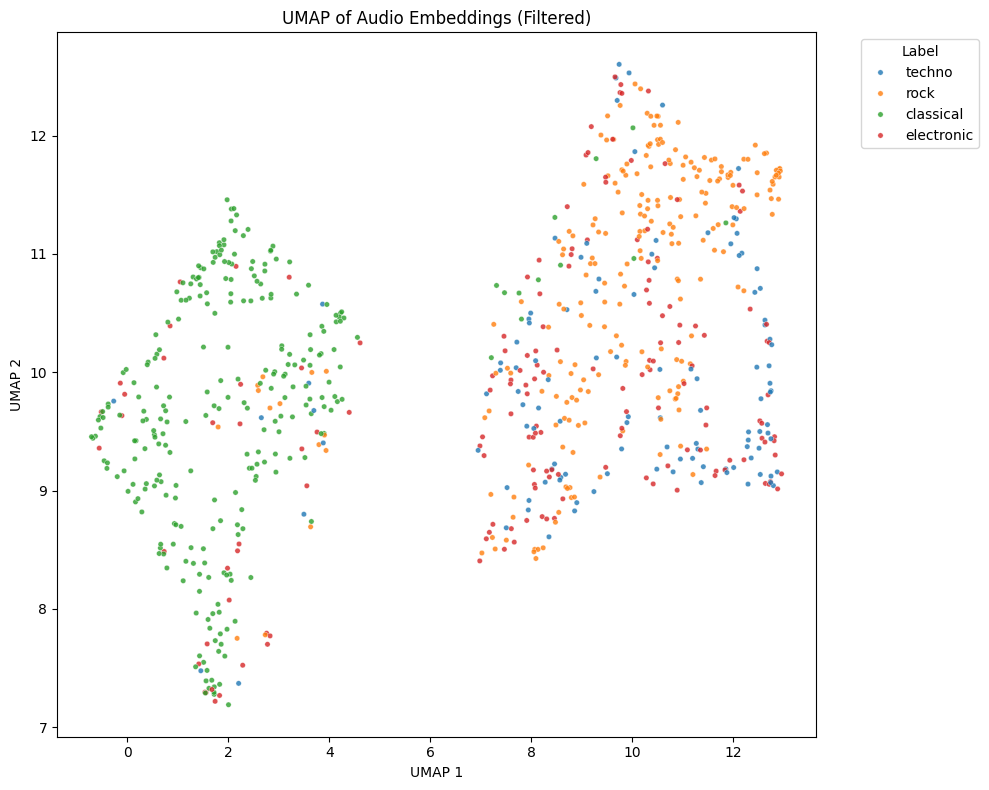

In [ ]:
# --- Example Usage ---

# Define the tags
my_tags = ["classical", "rock", "electronic", "techno"]

plot_mtat_embeddings(cnn, val_loader, priority_tags=my_tags)

### Training

In [ ]:
cnn_64_triplet_loss = CNN(dense_size=64, n_classes=64).to(device)

num_params = sum(p.numel() for p in cnn_64_triplet_loss.parameters() if p.requires_grad)
print(f"CNN Trainable parameters: {num_params}")

CNN Trainable parameters: 31616


In [ ]:
%%time

print("\nTraining model with the triplet loss")
# Setup training and save the results
train(cnn_64_triplet_loss, triplet_loss, n_epochs=10, device=device)


Training model with the triplet loss


Epoch 1/10:   0%|          | 0/37 [00:00<?, ?it/s]

   Train Loss: 0.7389 | Val Loss: 0.8713


Epoch 2/10:   0%|          | 0/37 [00:00<?, ?it/s]

   Train Loss: 0.5134 | Val Loss: 0.8410


...

   Train Loss: 0.2884 | Val Loss: 0.6956


Epoch 9/10:   0%|          | 0/37 [00:00<?, ?it/s]

   Train Loss: 0.2662 | Val Loss: 0.6678


Epoch 10/10:   0%|          | 0/37 [00:00<?, ?it/s]

   Train Loss: 0.2653 | Val Loss: 0.6901
CPU times: user 3h 51min 20s, sys: 3min 14s, total: 3h 54min 34s
Wall time: 1h 26min 51s


Extracting embeddings (Filtering for: ['classical', 'rock', 'electronic', 'techno'])...


  0%|          | 0/4 [00:00<?, ?it/s]

Running UMAP on 782 filtered samples...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


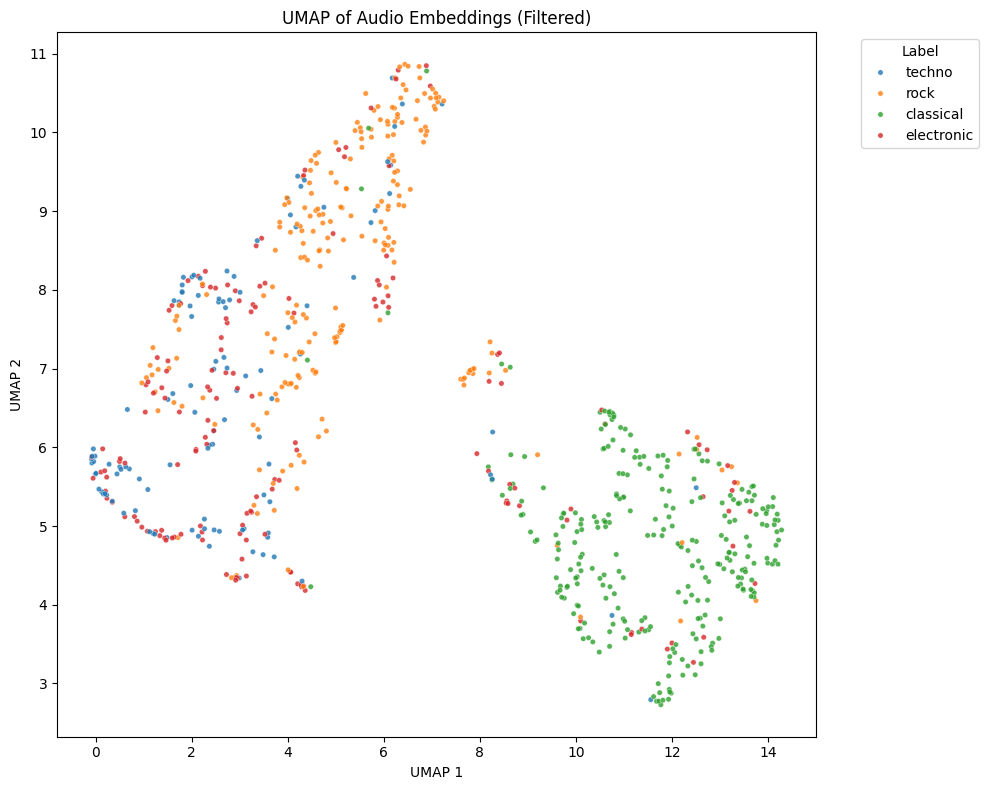

In [ ]:
# Define the tags
my_tags = ["classical", "rock", "electronic", "techno"]

plot_mtat_embeddings(cnn_64_triplet_loss, val_loader, priority_tags=my_tags)

In [ ]:
cnn_64_info_nce = CNN(dense_size=64, n_classes=64).to(device)

num_params = sum(p.numel() for p in cnn_64_info_nce.parameters() if p.requires_grad)
print(f"CNN Trainable parameters: {num_params}")

CNN Trainable parameters: 31616


In [ ]:
%%time

print("\nTraining model with the Info NCE")
# Setup training and save the results
train(cnn_64_info_nce, InfoNCE, n_epochs=10, device=device)


Training model with the Info NCE


Epoch 1/10:   0%|          | 0/37 [00:00<?, ?it/s]

   Train Loss: 5.8475 | Val Loss: 5.6063


Epoch 2/10:   0%|          | 0/37 [00:00<?, ?it/s]

   Train Loss: 5.5261 | Val Loss: 5.4131


...

   Train Loss: 5.2058 | Val Loss: 5.1733


Epoch 9/10:   0%|          | 0/37 [00:00<?, ?it/s]

   Train Loss: 5.1781 | Val Loss: 5.1643


Epoch 10/10:   0%|          | 0/37 [00:00<?, ?it/s]

   Train Loss: 5.1573 | Val Loss: 5.1424
CPU times: user 3h 50min 22s, sys: 4min 11s, total: 3h 54min 33s
Wall time: 1h 27min 9s


Extracting embeddings (Filtering for: ['classical', 'rock', 'electronic', 'techno'])...


  0%|          | 0/4 [00:00<?, ?it/s]

Running UMAP on 782 filtered samples...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


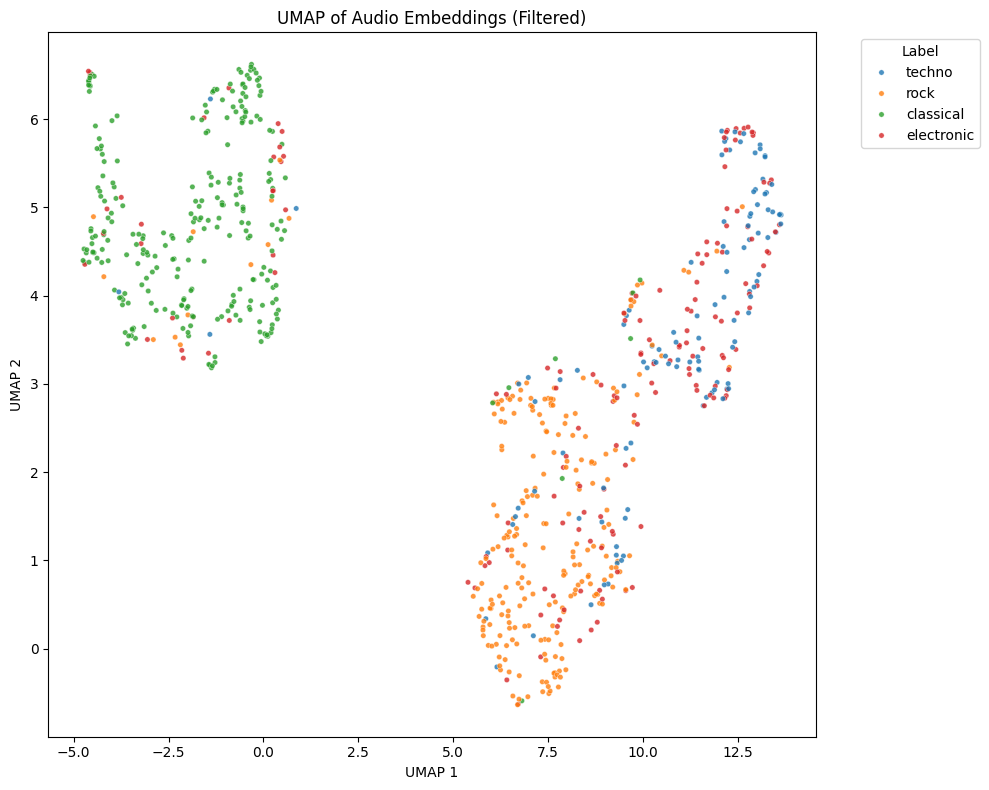

In [ ]:
# Define the tags
my_tags = ["classical", "rock", "electronic", "techno"]

plot_mtat_embeddings(cnn_64_info_nce, val_loader, priority_tags=my_tags)

## Results

In this project, I moved beyond traditional supervised classification to explore Metric Learning applied to music audio tagging. The core objective was to train a custom Convolutional Neural Network (CNN) to project audio samples from the MagnaTagATune dataset into a geometrically meaningful latent space. Instead of simply predicting labels, I aimed to learn an embedding manifold where distance equals semantic similarity. To achieve this, I used and compared two distinct learning paradigms: Triplet Loss and InfoNCE (Contrastive Learning), using a custom encoder architecture designed with aggressive pooling to efficiently capture spectral textures.

A consistent baseline observation across all experiments was the inherent separability of the "Classical" genre. Even in early training stages or with suboptimal loss functions, the model successfully isolated classical tracks into a distinct cluster, far removed from modern genres. This suggests that the spectral signature of classical music—characterized by harmonic complexity and a lack of repetitive percussive transients—is statistically distinct enough that the CNN’s feature extractor could disentangle it without requiring heavy optimization from the metric loss. The real challenge lay in differentiating between timbrally similar modern genres, specifically Rock, Electronic, and Techno.

The model trained with Triplet Loss provided a functional baseline but revealed limitations in fine-grained separation. While it successfully grouped samples of the same class, the resulting UMAP visualizations showed a dense, overlapping "cloud" containing Rock, Electronic, and Techno. This suggests that the pairwise comparison mechanism of Triplet Loss (Anchor-Positive-Negative) provided a gradient signal that was too weak or sparse to distinguish the subtle instrumental differences between Rock and Electronic music. It is likely that without an aggressive "hard negative mining" strategy, the model settled for a local minimum where these genres were simply grouped as "non-classical" rather than distinct styles.

In contrast, the model trained with InfoNCE demonstrated a superior ability to structure the embedding space. By leveraging a contrastive approach—where a positive sample is compared against a large set of negatives within the batch—the model was forced to learn much richer discriminative features. The results confirmed the hypothesis: the InfoNCE loss successfully pushed the "Rock" cluster away from the electronic genres, recognizing the timbral difference between guitar-based and synthesizer-based audio. This separation was not achieved with Triplet Loss, highlighting the efficiency of contrastive learning in maximizing mutual information for complex audio data.

Crucially, the experiment validated the semantic quality of the learned embeddings regarding the "Techno" and "Electronic" tags. In the final projections, these two categories remained heavily overlapped. Rather than viewing this as a classification error, I interpret this as a success of the metric learning approach. Since Techno is a subgenre of Electronic music with high sonic similarity, their proximity in the vector space confirms that the model learned true acoustic representations rather than just memorizing arbitrary text labels. The final space perfectly reflects the desired hierarchy: broad distinct genres (Classical vs. Modern) are far apart, distinct modern styles (Rock vs. Electronic) are separated, and subgenres (Techno/Electronic) share the same manifold.